# DATA 301 Final Project Code

**Team:** Arturo Ordaz-Gutiérrez, Lucas Summers, Jesus Avalos

In [ ]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("heesoo37/120-years-of-olympic-history-athletes-and-results")
df = pd.read_csv(path + "/athlete_events.csv")

Using Colab cache for faster access to the '120-years-of-olympic-history-athletes-and-results' dataset.


## Initial Data Cleaning

In [ ]:
def categorize_athletics(event):
    event = event.lower()
    if 'decathlon' in event or 'heptathlon' in event or 'pentathlon' in event or 'all-around' in event:
        return 'Combined'
    elif 'walk' in event:
        return 'Race Walks'
    elif 'relay' in event:
        return 'Relays'
    elif any(x in event for x in ['100 metres', '200 metres', '400 metres', '60 metres', '110 metres', '80 metres']):
        return 'Sprints'
    elif any(x in event for x in ['800', '1,500', '5,000', '10,000', '3,000', 'marathon', 'cross-country', 'mile', '3,200', '2,500', '4,000', '2,590']):
        return 'Distance'
    elif any(x in event for x in ['high jump', 'long jump', 'triple jump', 'pole vault']):
        return 'Jumps'
    elif any(x in event for x in ['shot put', 'discus', 'javelin', 'hammer', 'weight throw', 'stone throw']):
        return 'Throws'
    else:
        return 'Other'

# Split up the 'Athletics' sport (has all the track and field events)
athletics_mask = df['Sport'] == 'Athletics'
df.loc[athletics_mask, 'Sport'] = df.loc[athletics_mask, 'Event'].apply(categorize_athletics)

# Create binary target variable (medal or no medal)
df['Medal'] = df['Medal'].notna().astype(int)

# Drop unnecessary/redundant columns
columns_to_drop = ['ID', 'Name', 'Games', 'Event', 'Team', 'City']
df = df.drop(columns=columns_to_drop)

df.head()

,Sex,Age,Height,Weight,NOC,Year,Season,Sport,Medal
0,M,24.0,180.0,80.0,CHN,1992,Summer,Basketball,0
1,M,23.0,170.0,60.0,CHN,2012,Summer,Judo,0
2,M,24.0,NaN,NaN,DEN,1920,Summer,Football,0
3,M,34.0,NaN,NaN,DEN,1900,Summer,Tug-Of-War,1
4,F,21.0,185.0,82.0,NED,1988,Winter,Speed Skating,0


## Set Up Train/Test Splits and Preprocessing Pipeline

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

ct = make_column_transformer(
  (make_pipeline(SimpleImputer(strategy='median'), StandardScaler()),
    make_column_selector(dtype_include='number')),
  (OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    make_column_selector(dtype_include='object'))
)

X = df.drop('Medal', axis=1)
y = df['Medal']
features = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X[features],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (216892, 8)
Testing data shape: (54224, 8)


## Grid Search (Logistic Regression vs. Decision Trees)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_grids = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=2000),
        {
            'logisticregression__solver': ['liblinear'],
            'logisticregression__penalty': ['l1', 'l2'],
            'logisticregression__C': [0.01, 0.1, 1, 10]
        }
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        {
            'decisiontreeclassifier__max_depth': [5, 10, 15, 20],
            'decisiontreeclassifier__min_samples_split': [10, 25, 50],
            'decisiontreeclassifier__min_samples_leaf': [5, 10, 25],
            'decisiontreeclassifier__ccp_alpha': [0.0, 0.0005, 0.001]
        }
    )
}

model_rows = []
best_estimators = {}

for model_name, (model, param_grid) in model_grids.items():
    pipe = make_pipeline(ct, model)

    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )

    grid.fit(X_train, y_train)
    best_estimators[model_name] = grid.best_estimator_

    y_train_pred = grid.best_estimator_.predict(X_train)
    y_test_pred = grid.best_estimator_.predict(X_test)

    model_rows.append({
        'Model': model_name,
        'Best Params': str(grid.best_params_),
        'Mean CV F1': grid.best_score_,
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred)
    })

model_summary = pd.DataFrame(model_rows).sort_values('Mean CV F1', ascending=False).reset_index(drop=True)
model_summary


,Model,Best Params,Mean CV F1,Train F1,Test F1
0,Decision Tree,"{'decisiontreeclassifier__ccp_alpha': 0.0, 'de...",0.434219,0.468737,0.441764
1,Logistic Regression,"{'logisticregression__C': 0.1, 'logisticregres...",0.382876,0.383546,0.391169


In [ ]:
print(model_summary[['Model', 'Mean CV F1', 'Train F1', 'Test F1']].to_string(index=False))

for _, row in model_summary.iterrows():
    model_name = row['Model']
    estimator = best_estimators[model_name]
    y_pred = estimator.predict(X_test)

    print()
    print('=' * 60)
    print(f'  {model_name}')
    print('=' * 60)
    print(f"Best params: {row['Best Params']}")
    print(f"Best CV F1:  {row['Mean CV F1']:.4f}")
    print(f"Train F1:    {row['Train F1']:.4f}")
    print(f"Test F1:     {row['Test F1']:.4f}")
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))


              Model  Mean CV F1  Train F1  Test F1
      Decision Tree    0.434219  0.468737 0.441764
Logistic Regression    0.382876  0.383546 0.391169

  Decision Tree
Best params: {'decisiontreeclassifier__ccp_alpha': 0.0, 'decisiontreeclassifier__max_depth': 20, 'decisiontreeclassifier__min_samples_leaf': 5, 'decisiontreeclassifier__min_samples_split': 25}
Best CV F1:  0.4342
Train F1:    0.4687
Test F1:     0.4418

Classification Report:
              precision    recall  f1-score   support

    No Medal       0.92      0.80      0.86     46267
       Medal       0.35      0.61      0.44      7957

    accuracy                           0.77     54224
   macro avg       0.63      0.71      0.65     54224
weighted avg       0.84      0.77      0.80     54224


  Logistic Regression
Best params: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
Best CV F1:  0.3829
Train F1:    0.3835
Test F1:     0.3912

Classification Rep

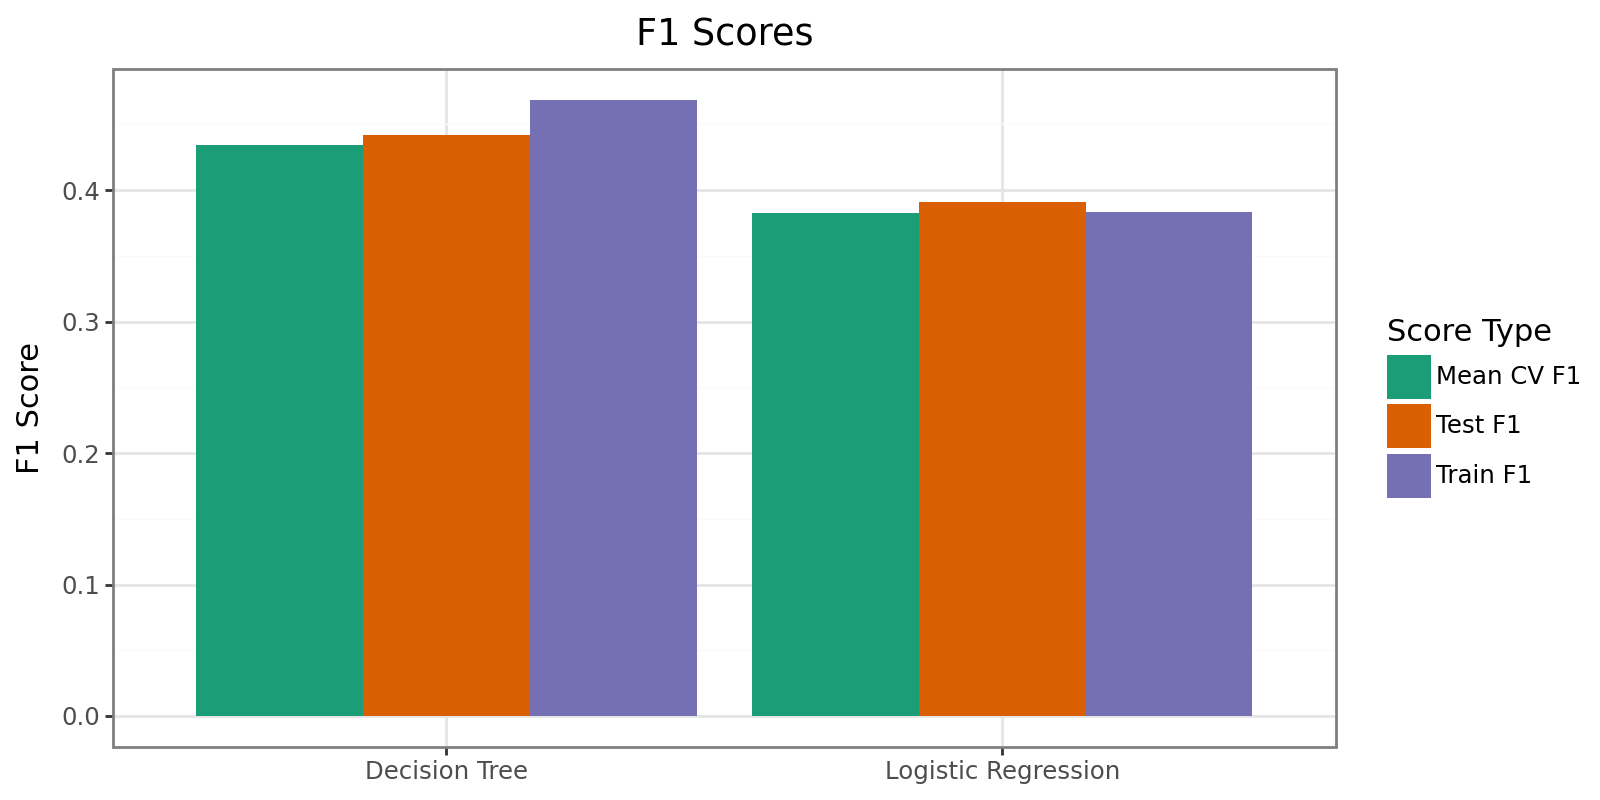

In [ ]:
from plotnine import *

plot_df = model_summary.melt(
    id_vars='Model',
    value_vars=['Mean CV F1', 'Train F1', 'Test F1'],
    var_name='Score Type',
    value_name='F1 Score'
)

(
    ggplot(plot_df, aes(x='Model', y='F1 Score', fill='Score Type'))
    + geom_col(position='dodge')
    + labs(title='F1 Scores', x='', y='F1 Score')
    + scale_fill_manual(values={'Mean CV F1': '#1b9e77', 'Train F1': '#7570b3', 'Test F1': '#d95f02'})
    + theme_bw()
    + theme(figure_size=(8, 4))
)


## Decision Tree Model Best Features

Best params: {'decisiontreeclassifier__ccp_alpha': 0.0, 'decisiontreeclassifier__max_depth': 20, 'decisiontreeclassifier__min_samples_leaf': 5, 'decisiontreeclassifier__min_samples_split': 25}
Depth: 20
Leaves: 1964


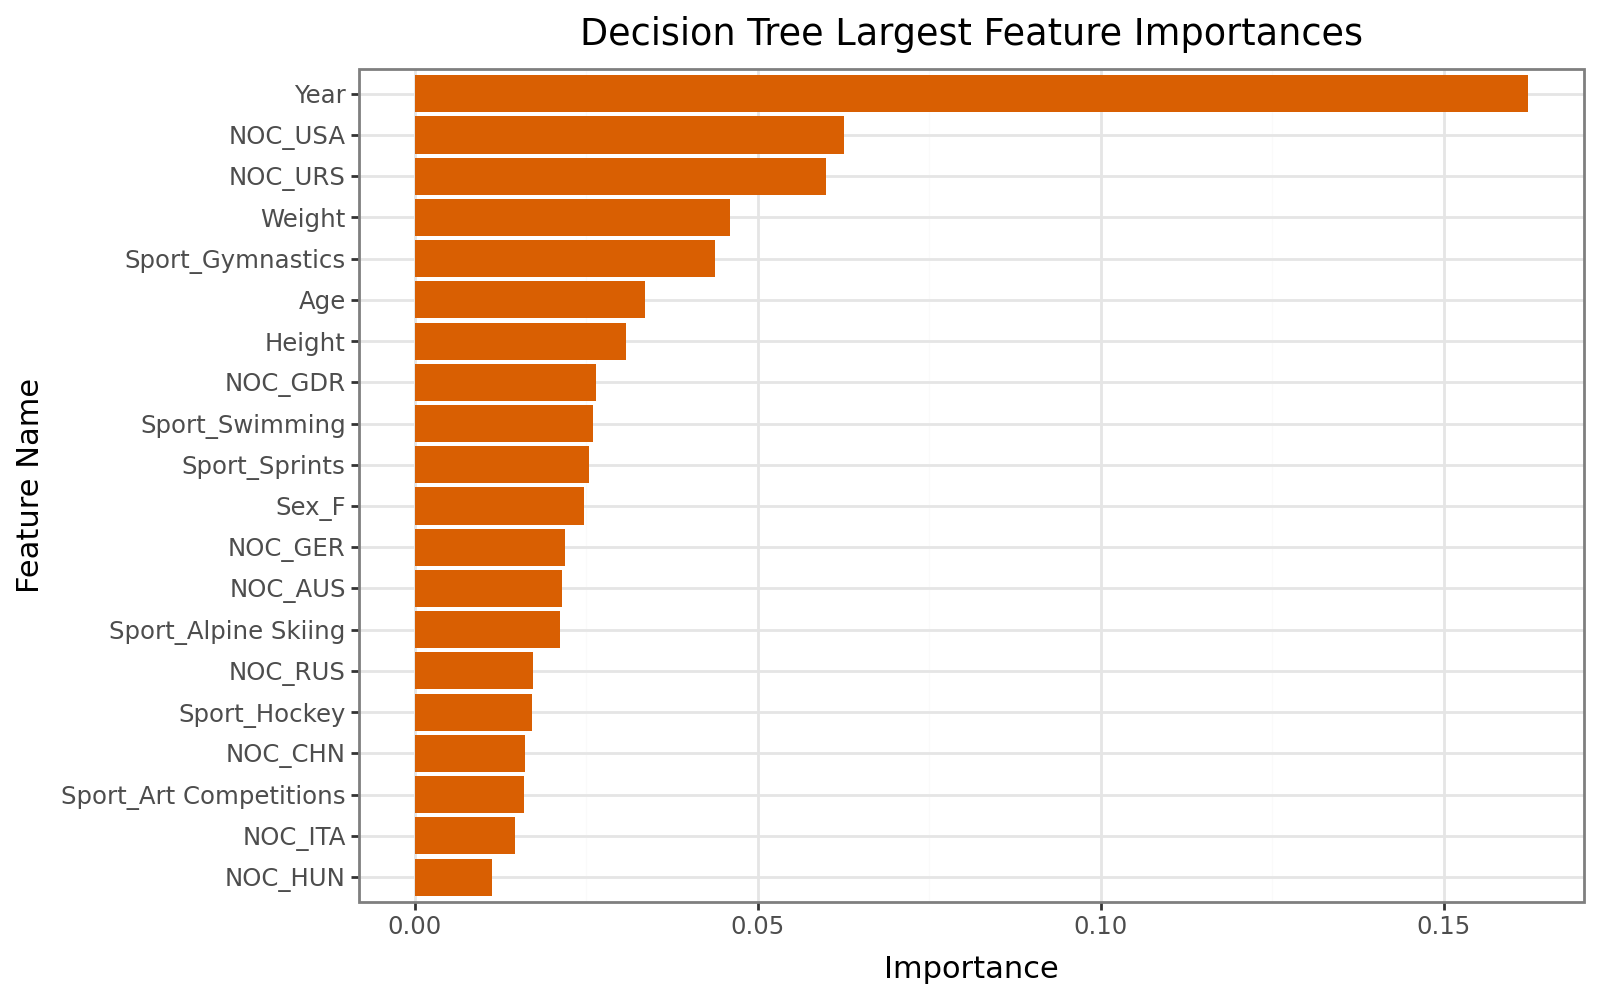

In [ ]:

model = DecisionTreeClassifier(
    ccp_alpha=0.0,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=25,
    class_weight="balanced",
    random_state=42
)
tree_pipe = make_pipeline(ct, model)
tree = tree_pipeline.named_steps['decisiontreeclassifier']

tree_params = model_summary.loc[model_summary['Model'] == 'Decision Tree', 'Best Params'].iloc[0]
print('Best params:', tree_params)
print('Depth:', tree.get_depth())
print('Leaves:', tree.get_n_leaves())

feature_names = tree_pipeline.named_steps['columntransformer'].get_feature_names_out()
feature_names = [name.split('__', 1)[-1] for name in feature_names]
importances = tree.feature_importances_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = coef_df.head(20).copy()
top_features['Feature'] = pd.Categorical(
    top_features['Feature'],
    categories=top_features['Feature'][::-1],
    ordered=True
)

(
    ggplot(top_features, aes(x='Feature', y='Importance'))
    + geom_col(fill='#d95f02')
    + coord_flip()
    + labs(title='Decision Tree Largest Feature Importances', x='Feature Name', y='Importance')
    + theme_bw()
    + theme(figure_size=(8, 5))
)

## Logistic Regression Model Best Features

Best params: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}


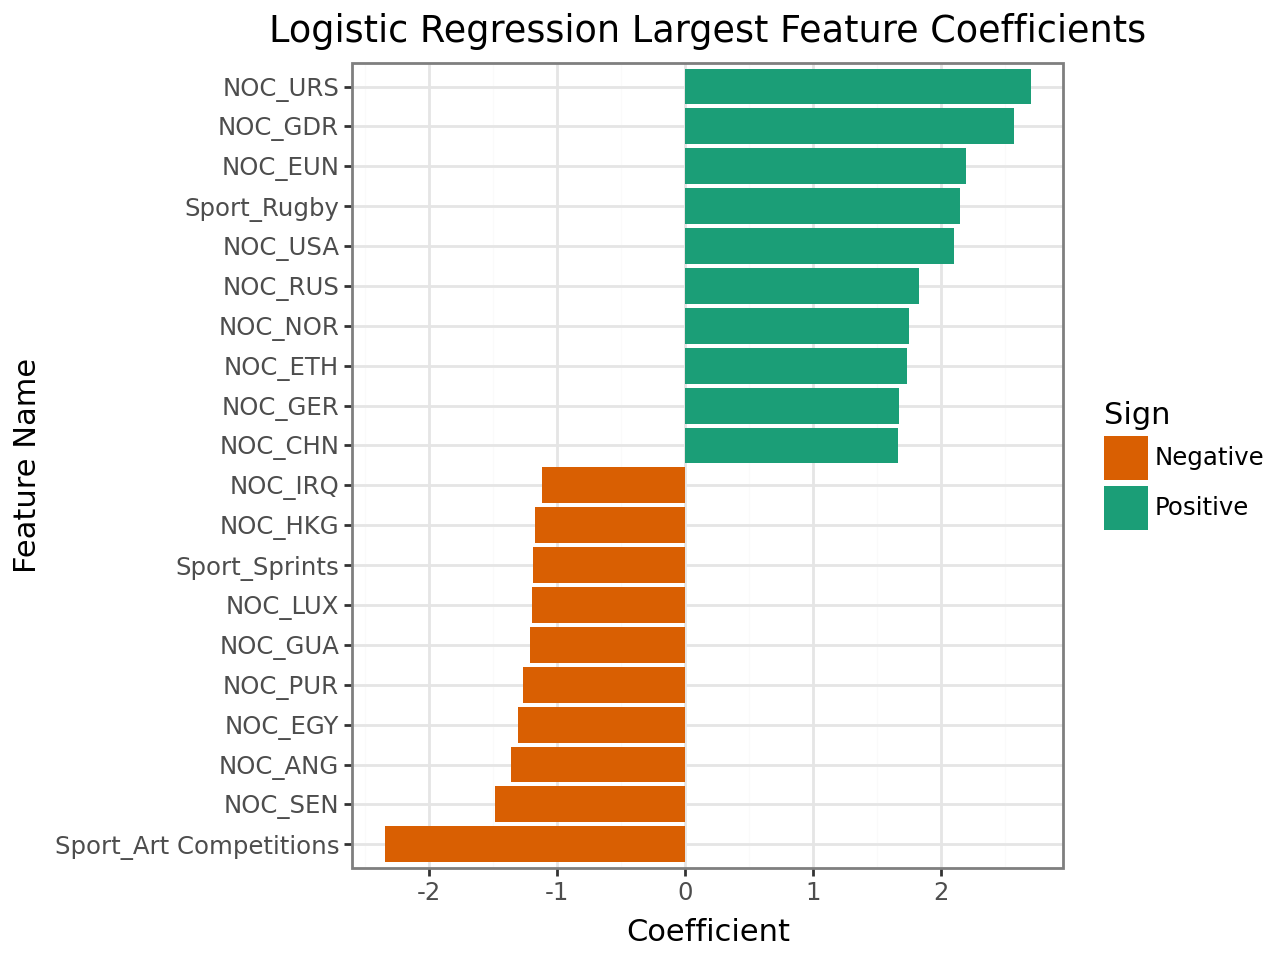

In [ ]:
import numpy as np

logit_pipeline = best_estimators['Logistic Regression']
logit_params = model_summary.loc[model_summary['Model'] == 'Logistic Regression', 'Best Params'].iloc[0]
print('Best params:', logit_params)

feature_names = logit_pipeline.named_steps['columntransformer'].get_feature_names_out()
feature_names = [name.split('__', 1)[-1] for name in feature_names]
coefficients = logit_pipeline.named_steps['logisticregression'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)
plot_df = pd.concat([top_positive, top_negative]).copy()
plot_df['Sign'] = np.where(plot_df['Coefficient'] > 0, 'Positive', 'Negative')
plot_df['Feature'] = pd.Categorical(
    plot_df['Feature'],
    categories=plot_df['Feature'][::-1],
    ordered=True
)

(
    ggplot(plot_df, aes(x='Feature', y='Coefficient', fill='Sign'))
    + geom_col()
    + coord_flip()
    + scale_fill_manual(values={'Positive': '#1b9e77', 'Negative': '#d95f02'})
    + labs(title='Logistic Regression Largest Feature Coefficients', x='Feature Name', y='Coefficient', fill='Sign')
    + theme_bw()
)

## Sport-Specific vs. Global Model Comparison

In [ ]:
from sklearn.base import clone
from sklearn.metrics import confusion_matrix

best_model_name = model_summary.iloc[0]['Model']
best_model = best_estimators[best_model_name]
top_10_sports = X_train['Sport'].value_counts().head(10).index

sport_rows = []

for sport in top_10_sports:

    train_mask = X_train['Sport'] == sport
    test_mask = X_test['Sport'] == sport

    X_train_sport = X_train.loc[train_mask]
    y_train_sport = y_train.loc[train_mask]
    X_test_sport = X_test.loc[test_mask]
    y_test_sport = y_test.loc[test_mask]

    if X_test_sport.empty or y_train_sport.nunique() < 2 or y_test_sport.nunique() < 2:
        continue

    sport_model = clone(best_model)
    sport_model.fit(X_train_sport, y_train_sport)

    global_preds = best_model.predict(X_test_sport)
    sport_preds = sport_model.predict(X_test_sport)

    g_tn, g_fp, g_fn, g_tp = confusion_matrix(y_test_sport, global_preds).ravel()
    s_tn, s_fp, s_fn, s_tp = confusion_matrix(y_test_sport, sport_preds).ravel()

    g_precision = g_tp / (g_tp + g_fp)
    g_recall = g_tp / (g_tp + g_fn)
    g_f1 = 2 * g_tp / (2 * g_tp + g_fp + g_fn)

    s_precision = s_tp / (s_tp + s_fp)
    s_recall = s_tp / (s_tp + s_fn)
    s_f1 = 2 * s_tp / (2 * s_tp + s_fp + s_fn)

    sport_rows.append({
        "Sport": sport,

        "Global Precision": g_precision,
        "Sport Precision": s_precision,
        "Global Recall": g_recall,
        "Sport Recall": s_recall,
        "Global F1": g_f1,

        "Sport F1": s_f1,

        "Test Rows": len(X_test_sport)
    })

print('Best global model:', best_model_name)

sport_comparison = (
    pd.DataFrame(sport_rows)
    .sort_values("Sport F1", ascending=False)
    .reset_index(drop=True)
)

sport_comparison

|index|Sport|Global Precision|Sport Precision|Global Recall|Sport Recall|Global F1|Sport F1|Test Rows|
|---|---|---|---|---|---|---|---|---|
|0|Rowing|0\.40349264705882354|0\.574438202247191|0\.7138211382113822|0\.6650406504065041|0\.5155607751027599|0\.6164280331574982|2085|
|1|Fencing|0\.3135483870967742|0\.4247787610619469|0\.6585365853658537|0\.7804878048780488|0\.42482517482517484|0\.5501432664756447|2201|
|2|Swimming|0\.4338677354709419|0\.4048821548821549|0\.712171052631579|0\.7911184210526315|0\.539227895392279|0\.5356347438752784|4646|
|3|Gymnastics|0\.31947069943289225|0\.28218562874251496|0\.7316017316017316|0\.816017316017316|0\.44473684210526315|0\.41935483870967744|5403|
|4|Cycling|0\.2780487804878049|0\.2907563025210084|0\.4453125|0\.67578125|0\.34234234234234234|0\.40658049353701525|2184|
|5|Shooting|0\.2263083451202263|0\.2578512396694215|0\.642570281124498|0\.6265060240963856|0\.33472803347280333|0\.36533957845433257|2305|
|6|Cross Country Skiing|0\.26506024096385544|0\.23821339950372208|0\.3464566929133858|0\.7559055118110236|0\.3003412969283277|0\.3622641509433962|1804|
|7|Sprints|0\.27483443708609273|0\.20608899297423888|0\.6916666666666667|0\.7333333333333333|0\.3933649289099526|0\.3217550274223035|1963|
|8|Distance|0\.21529745042492918|0\.1919191919191919|0\.5241379310344828|0\.6551724137931034|0\.30522088353413657|0\.296875|1904|
|9|Alpine Skiing|0\.171875|0\.1387434554973822|0\.5432098765432098|0\.654320987654321|0\.26112759643916916|0\.22894168466522677|1792|

In [ ]:
plot_df = sport_comparison.melt(
    id_vars=['Sport', 'Test Rows'],
    value_vars=[
        'Global Precision', 'Sport Precision',
        'Global Recall', 'Sport Recall'
    ]
)

precision_df = plot_df[plot_df['variable'].str.contains('Precision')].copy()
recall_df = plot_df[plot_df['variable'].str.contains('Recall')].copy()

precision_df['Model Type'] = precision_df['variable'].str.replace(' Precision','')
recall_df['Model Type'] = recall_df['variable'].str.replace(' Recall','')

precision_df = precision_df.rename(columns={'value':'Precision'})
recall_df = recall_df.rename(columns={'value':'Recall'})

merged_df = precision_df[['Sport','Model Type','Precision']].merge(
    recall_df[['Sport','Model Type','Recall']],
    on=['Sport','Model Type']
)

merged_df["F1"] = 2 * (
    merged_df["Precision"] * merged_df["Recall"]
) / (
    merged_df["Precision"] + merged_df["Recall"]
)

merged_df["Label"] = merged_df["Sport"] + " (" + merged_df["F1"].round(2).astype(str) + ")"

(
    ggplot(merged_df, aes(x='Recall', y='Precision', color='Model Type'))
    + geom_point(size=3)
    + geom_text(aes(label='Label'), nudge_y=0.007, size=10)
    + labs(
        title='Precision vs Recall by Sport (f1-score)',
        x='Recall',
        y='Precision'
    )
    + scale_color_manual(values={
        'Global': '#7570b3',
        'Sport': '#1b9e77'
    })
    + theme_bw()
    + theme(figure_size=(11,9))
)

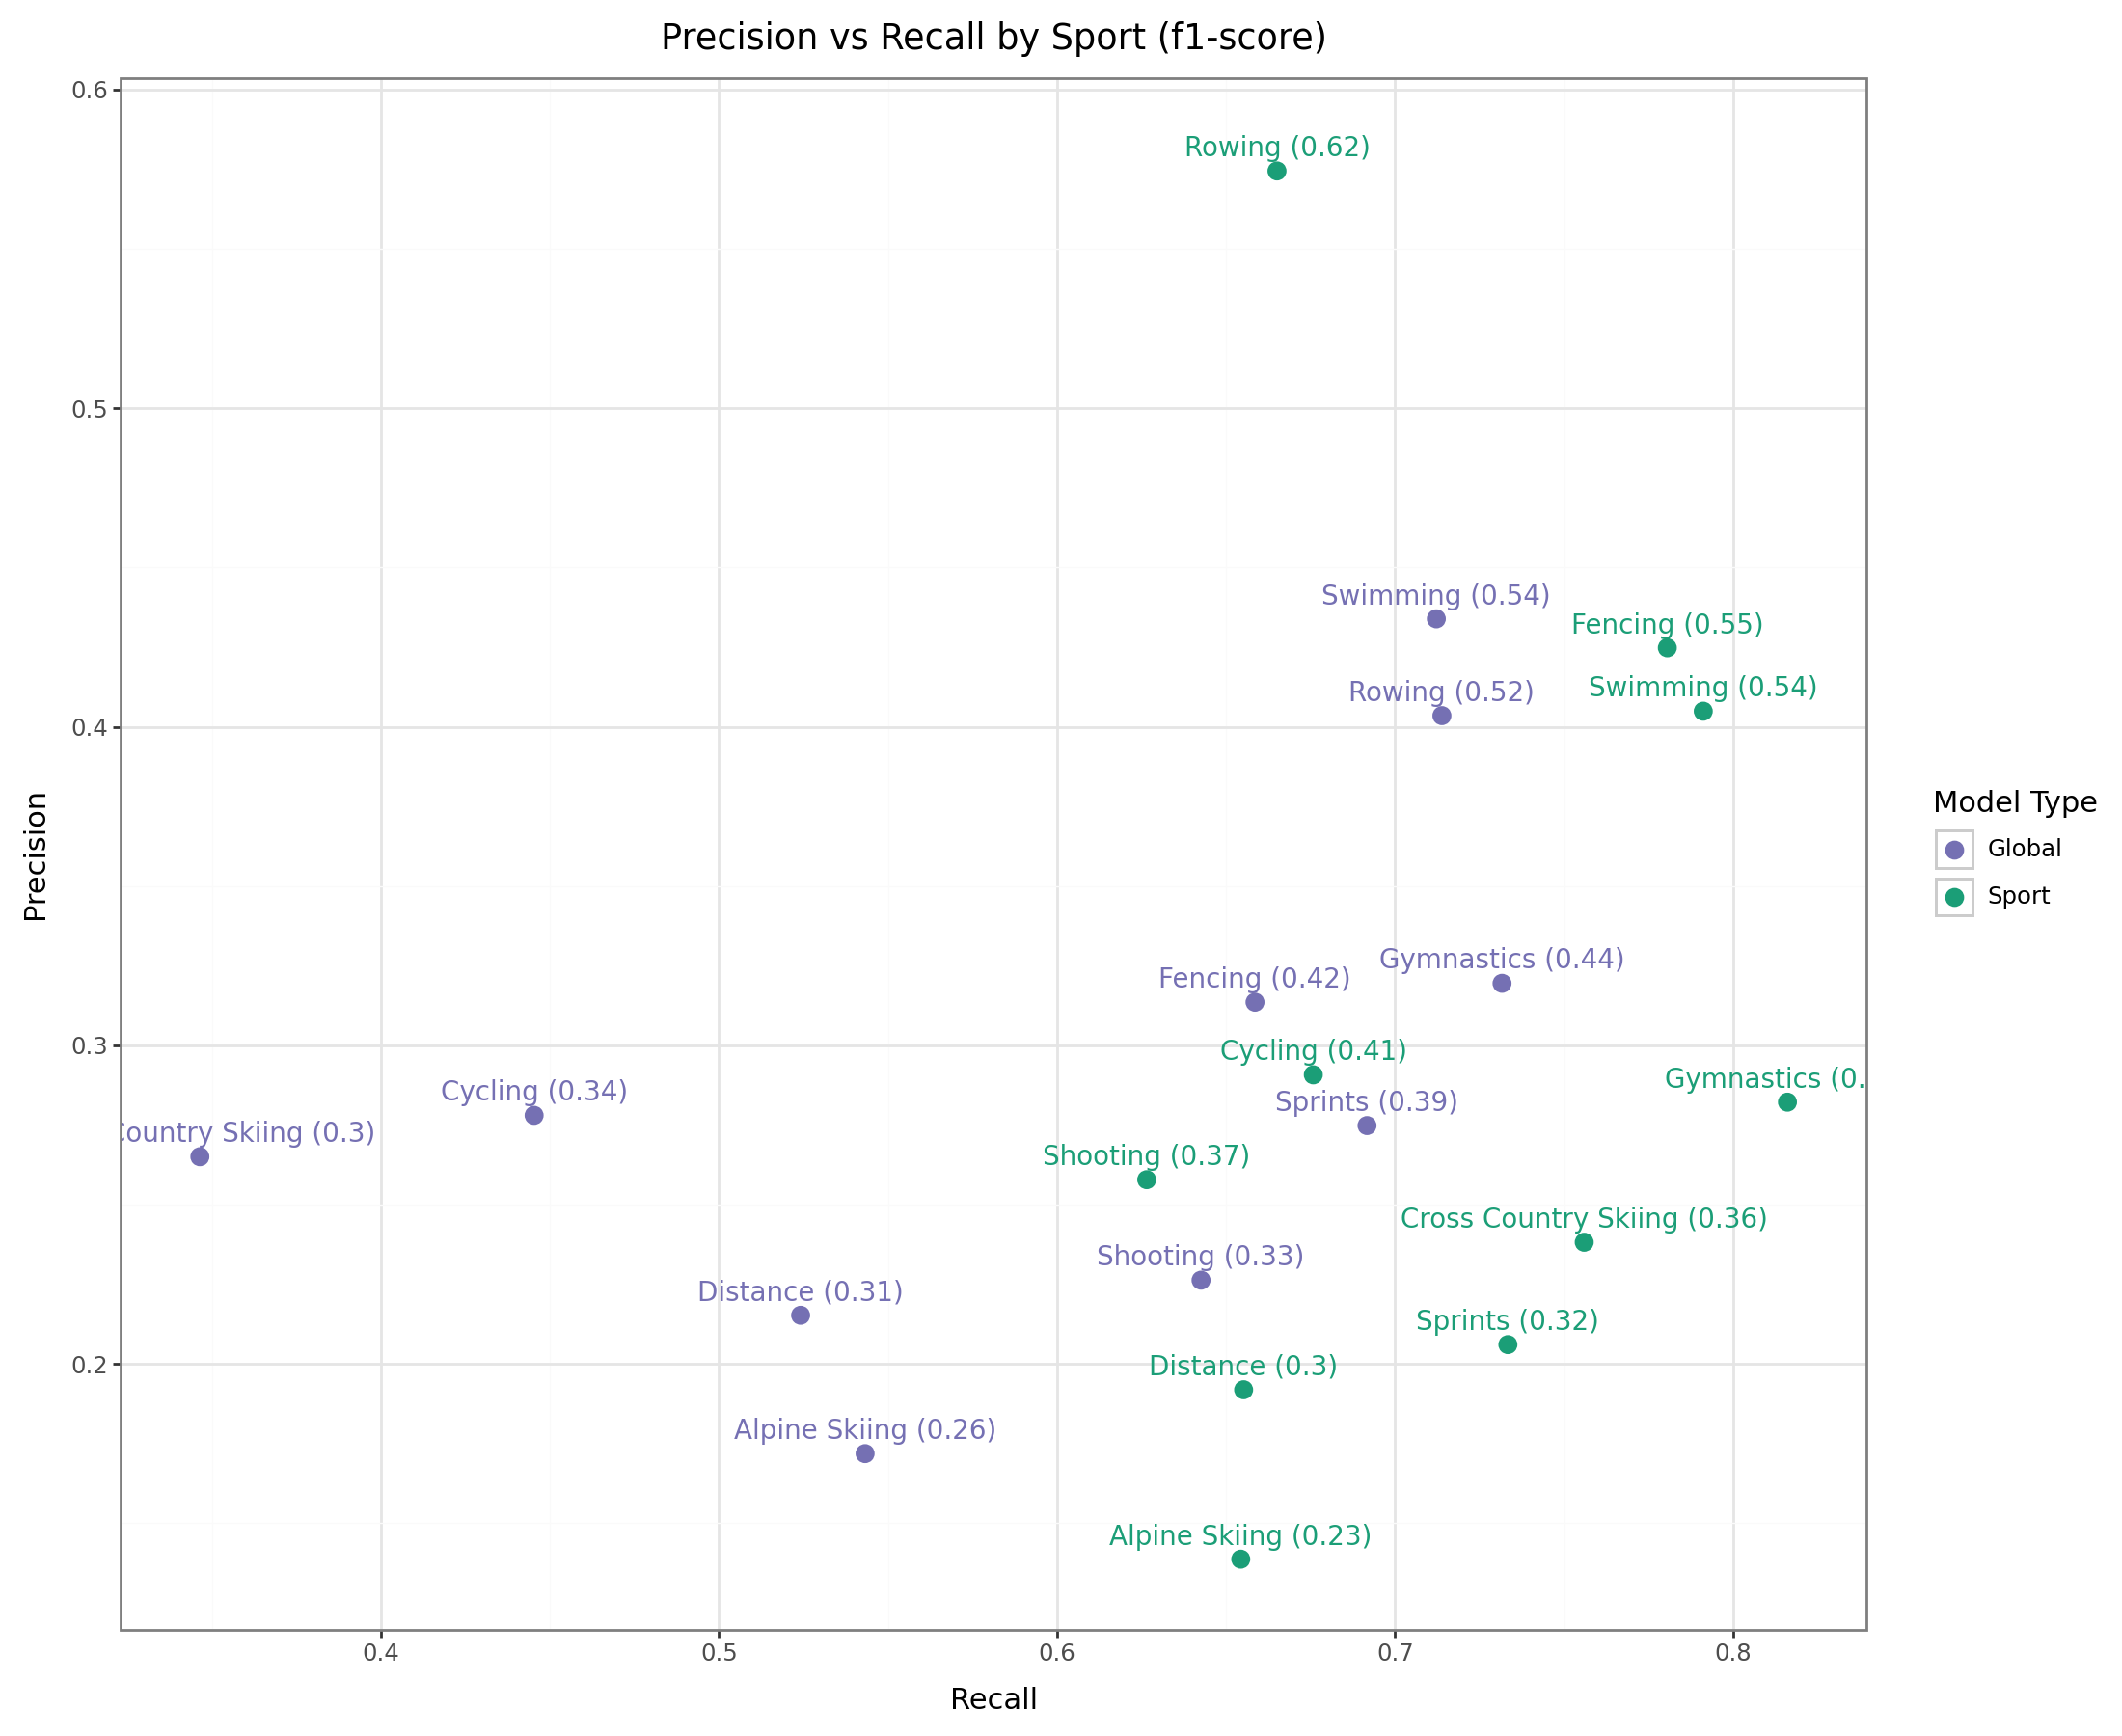

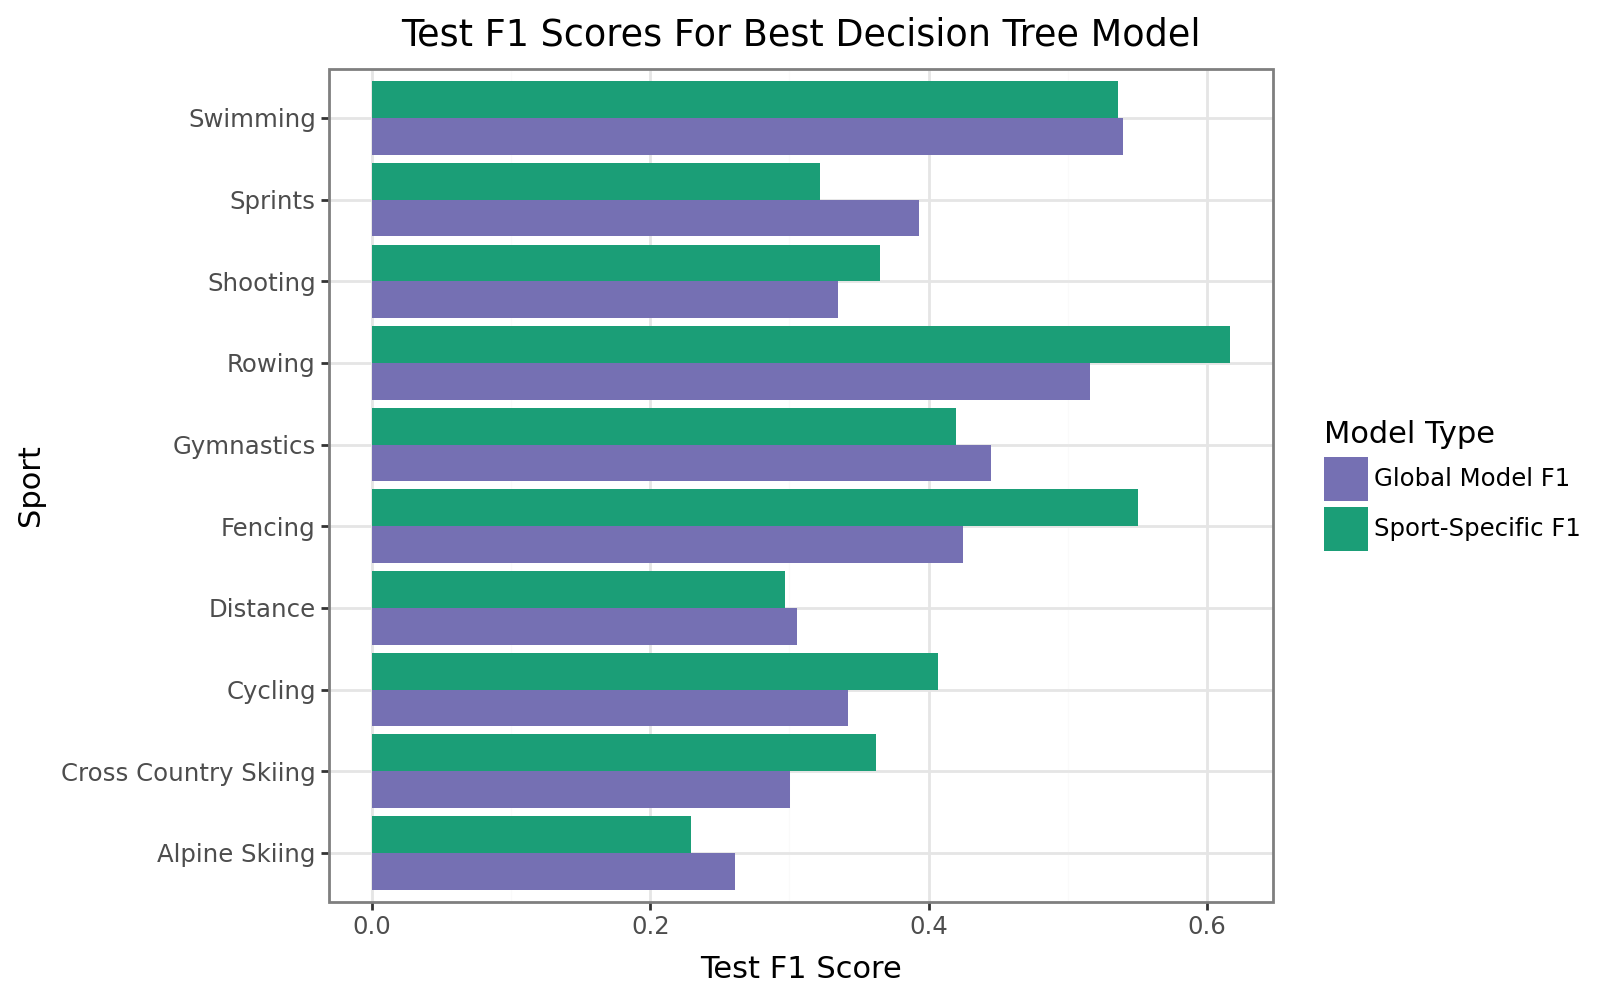

In [ ]:
plot_df = sport_comparison.melt(
    id_vars=['Sport', 'Test Rows'],
    value_vars=['Global Model F1', 'Sport-Specific F1'],
    var_name='Model Type',
    value_name='F1 Score'
)

(
    ggplot(plot_df, aes(x='Sport', y='F1 Score', fill='Model Type'))
    + geom_col(position='dodge')
    + coord_flip()
    + labs(title='Test F1 Scores For Best Decision Tree Model', x='Sport', y='Test F1 Score')
    + scale_fill_manual(values={'Global Model F1': '#7570b3', 'Sport-Specific F1': '#1b9e77'})
    + theme_bw()
    + theme(figure_size=(8, 5))
)
